In [ ]:
import pandas as pd

df=pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
df.shape

(284807, 31)

In [ ]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [ ]:
df.duplicated().sum()

np.int64(1081)

In [ ]:
import pandas as pd
import numpy as np

def create_raw_simulation(input_csv='creditcard.csv'):
    df = pd.read_csv(input_csv)
    np.random.seed(42)
    # Missing values
    for col in ['Amount', 'V1', 'V2']:

        mask = np.random.rand(len(df)) < 0.01

        df.loc[mask, col] = np.nan

    # Duplicate rows
    duplicates = df.sample(500, random_state=42)

    df = pd.concat(
        [df, duplicates],
        ignore_index=True
    )

    # Incorrect data types
    invalid_indices = df.sample(
        100,
        random_state=42
    ).index

    df.loc[invalid_indices, 'Amount'] = 'unknown'
    df.to_csv('raw_data.csv', index=False)

create_raw_simulation()

/tmp/ipykernel_19643/2081464726.py:28: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'unknown' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[invalid_indices, 'Amount'] = 'unknown'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# FRAUD DETECTION PIPELINE

class FraudDetectionPipeline:
    def __init__(self, file_path):

        self.file_path = file_path
        self.df = None
        self.scaler = StandardScaler()
    # 1: LOAD DATA

    def load_data(self):
        self.df = pd.read_csv(self.file_path)
        print(f"Dataset shape: {self.df.shape}")
        return self

    # 2: CLEAN DATA

    def clean_data(self):
        self.df['Amount'] = pd.to_numeric(
            self.df['Amount'],
            errors='coerce'
        )

        # Remove duplicates
        before_duplicates = len(self.df)
        self.df.drop_duplicates(inplace=True)
        after_duplicates = len(self.df)
        print(f"Removed duplicates: {before_duplicates - after_duplicates}")

        # Fill missing values in Amount
        self.df['Amount'] = self.df['Amount'].fillna(
            self.df['Amount'].median()
        )

        # Fill missing values only in feature columns
        feature_cols = self.df.columns.drop('Class')

        self.df[feature_cols] = self.df[feature_cols].fillna(
            self.df[feature_cols].mean()
        )

        # Remove rows where target is missing
        self.df = self.df.dropna(subset=['Class'])

        # Convert target to integer
        self.df['Class'] = self.df['Class'].astype(int)
        # Check remaining missing values
        print(f"Remaining NaN values: {self.df.isnull().sum().sum()}")
        print("\nClass Distribution:")
        print(self.df['Class'].value_counts())
        return self

    # 3: FEATURE ENGINEERING

    def feature_engineering(self):
        # Create Hour feature
        self.df['Hour'] = (self.df['Time'] // 3600) % 24

        # Log transformation for Amount
        self.df['Log_Amount'] = np.log1p(self.df['Amount'])
        self.df.drop(['Time', 'Amount'], axis=1, inplace=True)
        return self

    # 4: PREPARE DATA

    def prepare_data(self, use_smote=True):
        X = self.df.drop('Class', axis=1)
        y = self.df['Class']
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42,
            stratify=y
        )

        print(f"Train shape: {X_train.shape}")
        print(f"Test shape: {X_test.shape}")

        # Scaling
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        #SMOTE
        if use_smote:
            smote = SMOTE(random_state=42)
            X_train_resampled, y_train_resampled = smote.fit_resample(
                X_train_scaled,
                y_train
            )

            print("Before SMOTE:")
            print(y_train.value_counts())

            print("\nAfter SMOTE:")
            print(pd.Series(y_train_resampled).value_counts())

            return (
                X_train_resampled,
                X_test_scaled,
                y_train_resampled,
                y_test
            )

        return (
            X_train_scaled,
            X_test_scaled,
            y_train,
            y_test
        )


#PIPELINE

pipeline = FraudDetectionPipeline('creditcard.csv')
X_train, X_test, y_train, y_test = (
    pipeline
    .load_data()
    .clean_data()
    .feature_engineering()
    .prepare_data(use_smote=True)
)

Dataset shape: (284807, 31)
Removed duplicates: 1081
Remaining NaN values: 0

Class Distribution:
Class
0    283253
1       473
Name: count, dtype: int64
Train shape: (226980, 30)
Test shape: (56746, 30)
Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64



 Exploratory Data Analysis 
Normal Transactions: 99.83%
Fraud Transactions: 0.17%


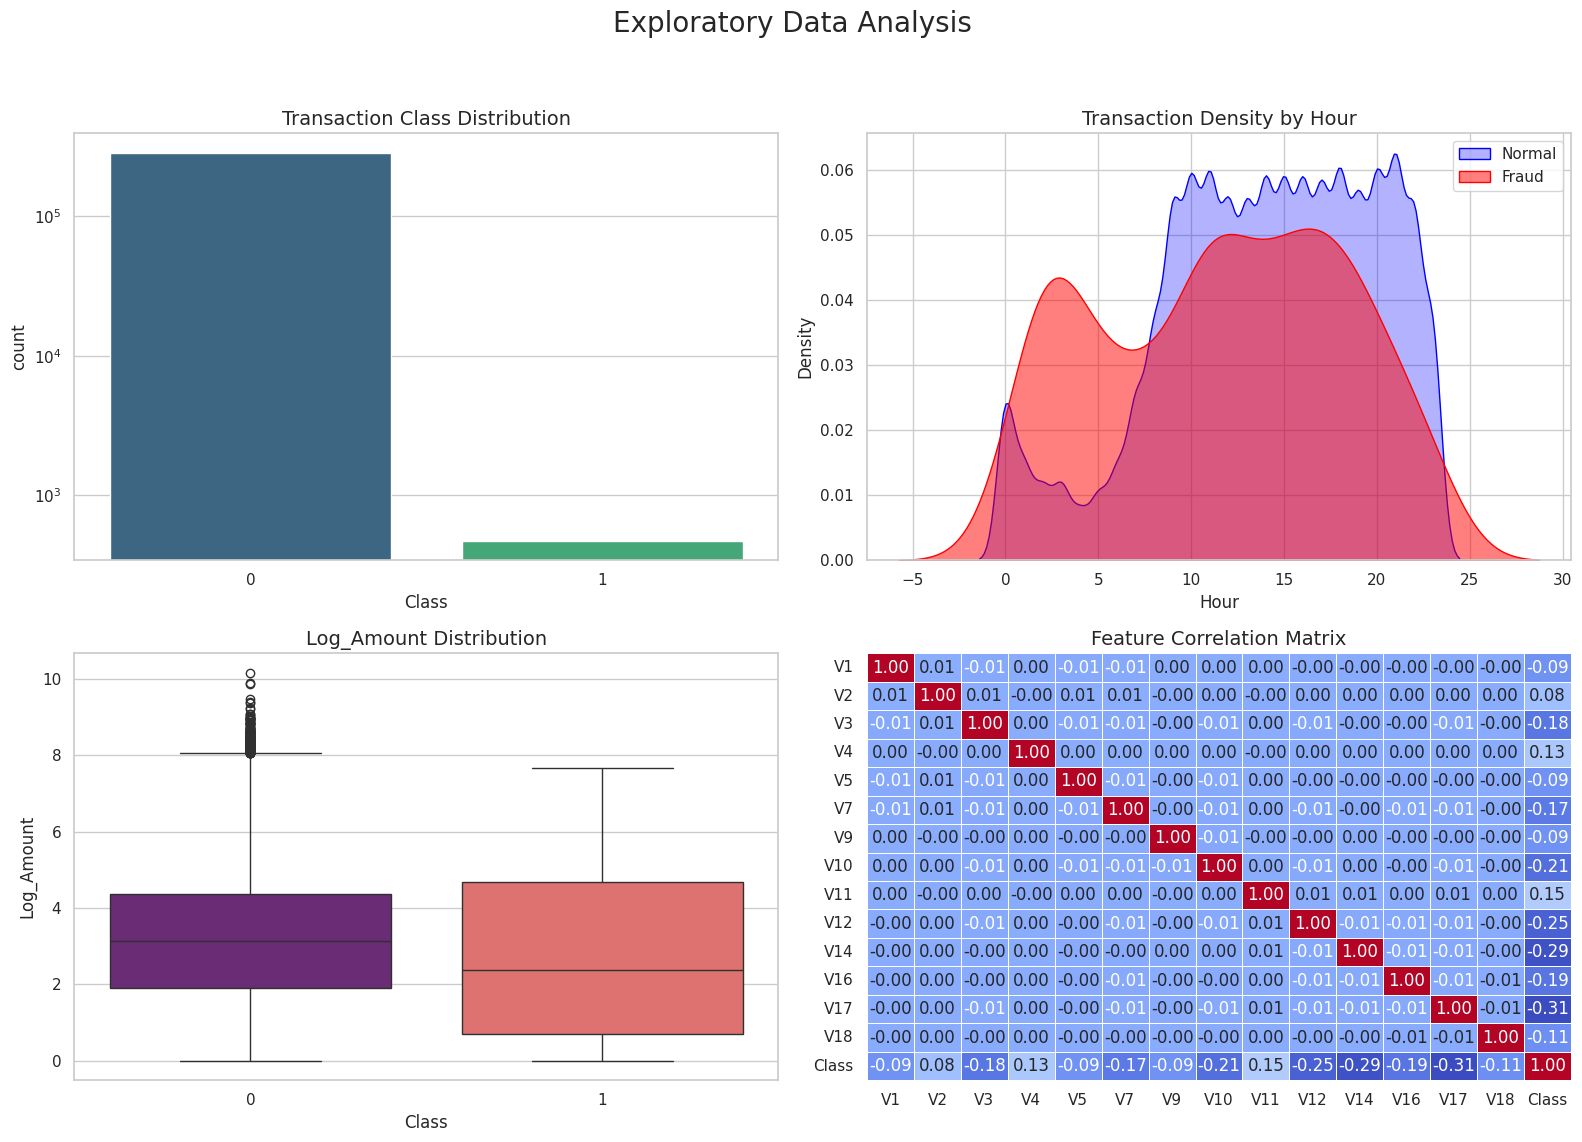

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
def perform_full_eda(df):

    sns.set_theme(style="whitegrid")
    counts = df['Class'].value_counts(normalize=True) * 100
    print("\n Exploratory Data Analysis ")
    print(f"Normal Transactions: {counts[0]:.2f}%")
    print(f"Fraud Transactions: {counts[1]:.2f}%")

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(16, 12)
    )

    fig.suptitle(
        'Exploratory Data Analysis',
        fontsize=20
    )
    # CLASS DISTRIBUTION
    sns.countplot(
        x='Class',
        data=df,
        hue='Class',
        palette='viridis',
        legend=False,
        ax=axes[0, 0]
    )

    axes[0, 0].set_title(
        'Transaction Class Distribution',
        fontsize=14
    )

    axes[0, 0].set_yscale('log')

    # TEMPORAL PATTERNS
    sns.kdeplot(
        df[df['Class'] == 0]['Hour'],
        label='Normal',
        fill=True,
        color='blue',
        alpha=0.3,
        ax=axes[0, 1]
    )

    sns.kdeplot(
        df[df['Class'] == 1]['Hour'],
        label='Fraud',
        fill=True,
        color='red',
        alpha=0.5,
        ax=axes[0, 1]
    )

    axes[0, 1].set_title(
        'Transaction Density by Hour',
        fontsize=14
    )

    axes[0, 1].legend()

    # LOG AMOUNT DISTRIBUTION
    sns.boxplot(
        x='Class',
        y='Log_Amount',
        data=df,
        hue='Class',
        palette='magma',
        legend=False,
        ax=axes[1, 0]
    )

    axes[1, 0].set_title(
        'Log_Amount Distribution',
        fontsize=14
    )

    # CORRELATION MATRIX
    corr = df.corr()
    relevant_features = corr.index[
        abs(corr['Class']) > 0.05
    ]

    sns.heatmap(
    df[relevant_features].corr(),
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    ax=axes[1, 1],
    cbar=False
)
    axes[1, 1].set_title(
        'Feature Correlation Matrix',
        fontsize=14
    )

    plt.tight_layout(
        rect=[0, 0.03, 1, 0.95]
    )

    plt.show()


perform_full_eda(pipeline.df)

TRAINING MODEL: Logistic Regression

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746

ROC-AUC: 0.9597
PR-AUC: 0.6825
TRAINING MODEL: Random Forest

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.58      0.79      0.67        95

    accuracy                           1.00     56746
   macro avg       0.79      0.89      0.83     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9824
PR-AUC: 0.7725
TRAINING MODEL: XGBoost

 Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
          

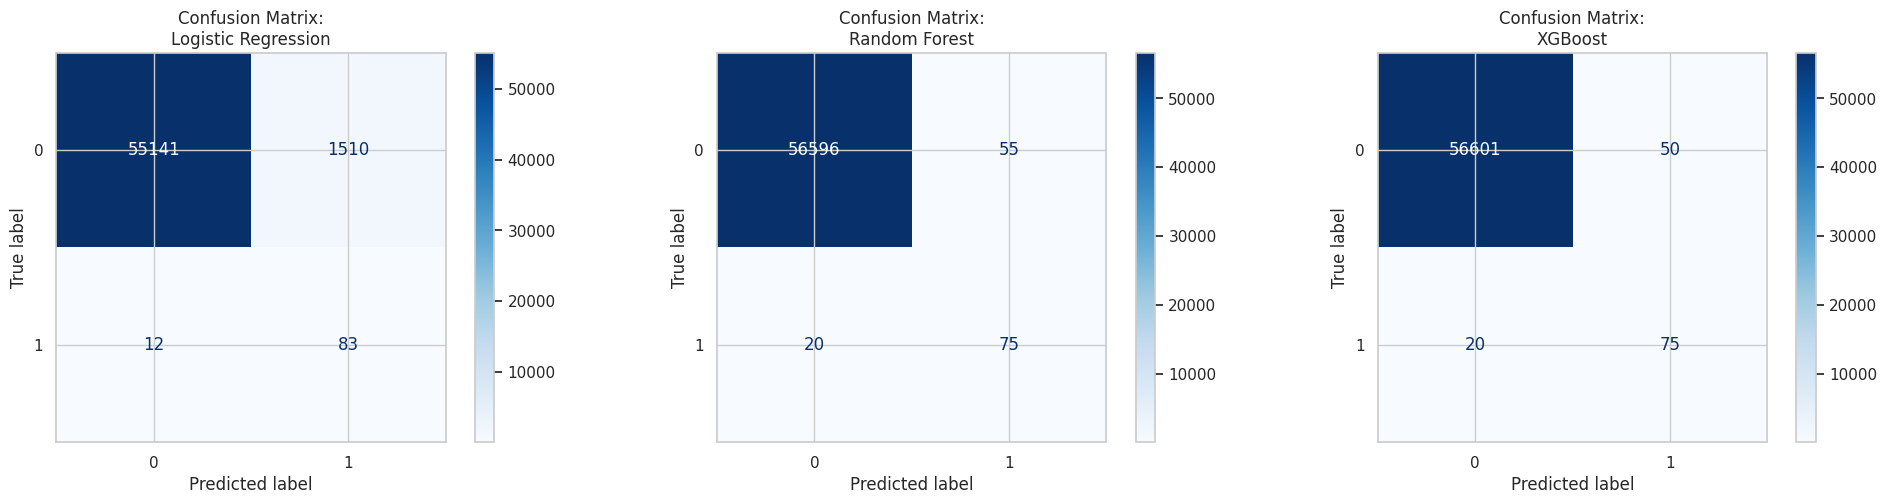

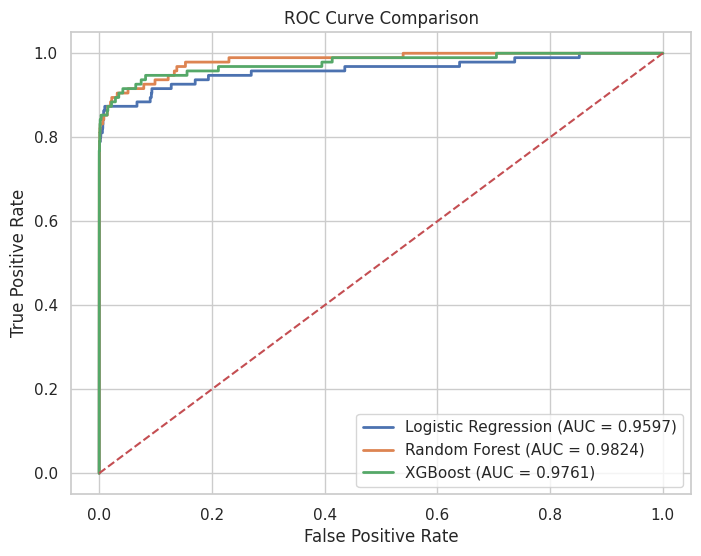

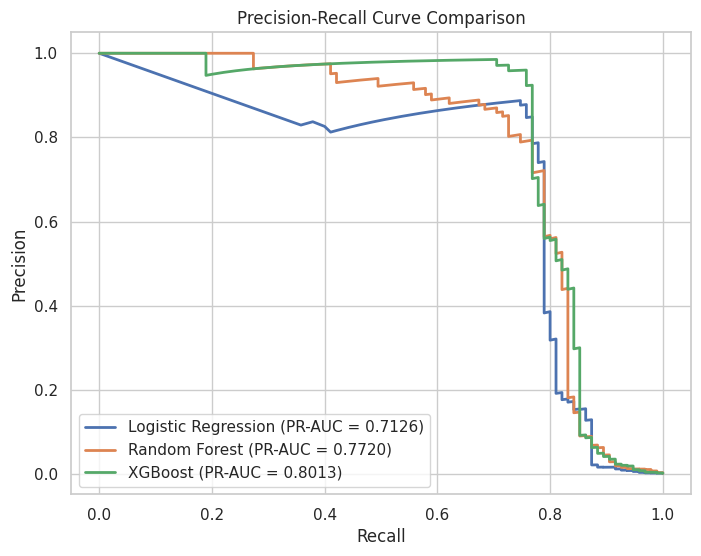

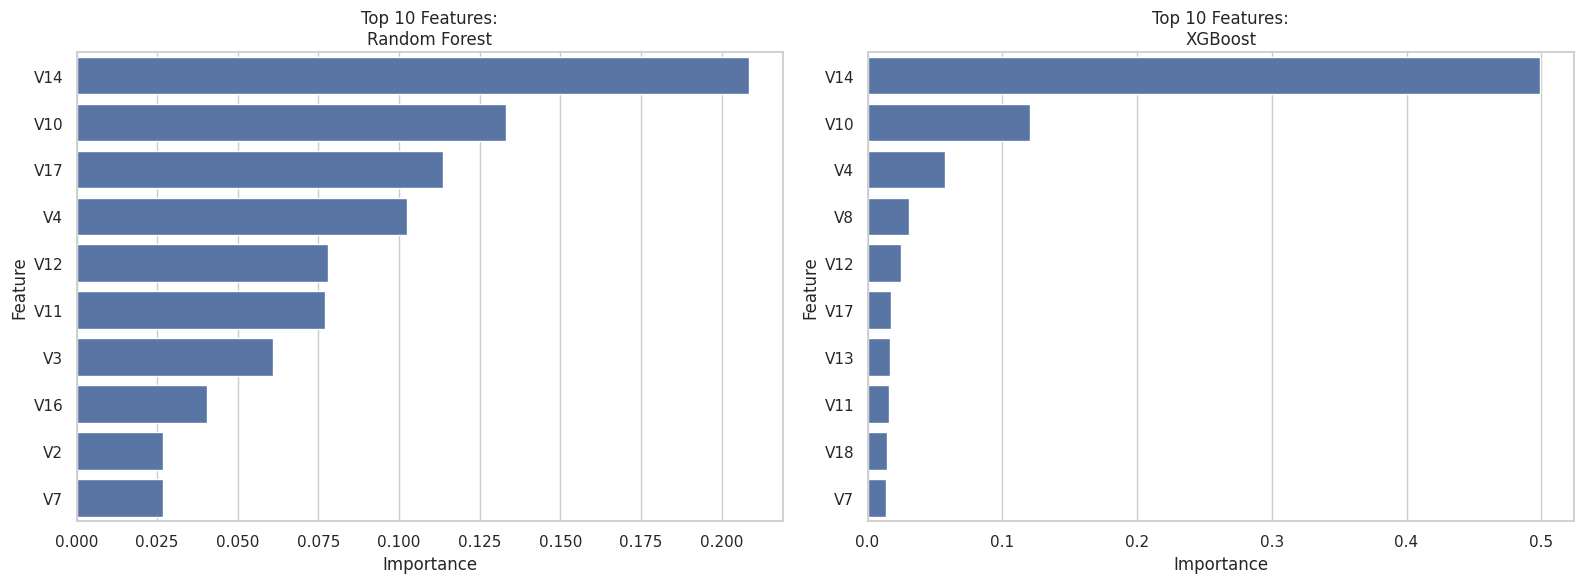

FINAL MODEL SELECTION

Best Model: XGBoost
PR-AUC: 0.8016
F1-Score: 0.6818
Recall: 0.7895
Precision: 0.6


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve,
    auc
)

class FraudModelExperiment:

    def __init__(self, X_train, X_test, y_train, y_test, feature_names):
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        self.feature_names = feature_names

        self.models = {}
        self.results = []

    # TRAIN & EVALUATE MODELS

    def run_experiments(self):

        model_list = {

            "Logistic Regression": LogisticRegression(
                max_iter=1000,
                random_state=42
            ),

            "Random Forest": RandomForestClassifier(
                n_estimators=150,
                max_depth=10,
                random_state=42,
                n_jobs=-1
            ),

            "XGBoost": XGBClassifier(
                n_estimators=150,
                learning_rate=0.1,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric='logloss'
            )
        }

        for name, model in model_list.items():

            print(f"TRAINING MODEL: {name}")
            model.fit(self.X_train, self.y_train)
            self.models[name] = model
            y_pred = model.predict(self.X_test)
            y_probs = model.predict_proba(self.X_test)[:, 1]

            # Metrics
            precision = precision_score(self.y_test, y_pred)
            recall = recall_score(self.y_test, y_pred)
            f1 = f1_score(self.y_test, y_pred)
            roc_auc = roc_auc_score(self.y_test, y_probs)
            pr_auc = average_precision_score(self.y_test, y_probs)

            self.results.append({

                "Model": name,
                "Precision": round(precision, 4),
                "Recall": round(recall, 4),
                "F1-Score": round(f1, 4),
                "ROC-AUC": round(roc_auc, 4),
                "PR-AUC": round(pr_auc, 4)
            })

            print("\n Classification Report:")
            print(classification_report(self.y_test, y_pred))

            print(f"ROC-AUC: {roc_auc:.4f}")
            print(f"PR-AUC: {pr_auc:.4f}")

    # RESULTS TABLE
    def get_comparison_table(self):
        results_df = pd.DataFrame(self.results)
        return results_df.sort_values(
            by="PR-AUC",
            ascending=False
        )

    # CONFUSION MATRICES
    def plot_confusion_matrices(self):
        fig, axes = plt.subplots(1, 3, figsize=(20, 5))
        for i, (name, model) in enumerate(self.models.items()):

            ConfusionMatrixDisplay.from_estimator(
                model,
                self.X_test,
                self.y_test,
                cmap='Blues',
                ax=axes[i]
            )

            axes[i].set_title(f"Confusion Matrix:\n{name}")

        plt.tight_layout()
        plt.show()

    # ROC CURVES
    def plot_roc_curves(self):
        plt.figure(figsize=(8, 6))
        for name, model in self.models.items():
            y_probs = model.predict_proba(self.X_test)[:, 1]
            fpr, tpr, _ = roc_curve(self.y_test, y_probs)
            roc_auc = auc(fpr, tpr)
            plt.plot(
                fpr,
                tpr,
                linewidth=2,
                label=f"{name} (AUC = {roc_auc:.4f})"
            )

        plt.plot([0, 1], [0, 1], linestyle='--')

        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve Comparison")
        plt.legend()
        plt.grid(True)
        plt.show()

    # PRECISION-RECALL CURVES
    def plot_pr_curves(self):
        plt.figure(figsize=(8, 6))
        for name, model in self.models.items():

            y_probs = model.predict_proba(self.X_test)[:, 1]
            precision, recall, _ = precision_recall_curve(
                self.y_test,
                y_probs
            )

            pr_auc = auc(recall, precision)

            plt.plot(
                recall,
                precision,
                linewidth=2,
                label=f"{name} (PR-AUC = {pr_auc:.4f})"
            )

        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title("Precision-Recall Curve Comparison")
        plt.legend()
        plt.grid(True)
        plt.show()

    # FEATURE IMPORTANCE
    def plot_feature_importance(self):
        important_models = [
            model_name
            for model_name in self.models
            if hasattr(self.models[model_name], 'feature_importances_')
        ]

        fig, axes = plt.subplots(
            1,
            len(important_models),
            figsize=(16, 6)
        )

        if len(important_models) == 1:
            axes = [axes]
        for ax, model_name in zip(axes, important_models):
            model = self.models[model_name]
            importances = model.feature_importances_
            feature_importance_df = pd.DataFrame({

                'Feature': self.feature_names,
                'Importance': importances
            })

            feature_importance_df = feature_importance_df.sort_values(
                by='Importance',
                ascending=False
            ).head(10)

            sns.barplot(
                data=feature_importance_df,
                x='Importance',
                y='Feature',
                ax=ax
            )

            ax.set_title(f"Top 10 Features:\n{model_name}")

        plt.tight_layout()
        plt.show()

    # FINAL MODEL SELECTION
    def final_recommendation(self):
        results_df = self.get_comparison_table()
        best_model = results_df.iloc[0]
        print("FINAL MODEL SELECTION")
        print(f"\nBest Model: {best_model['Model']}")
        print(f"PR-AUC: {best_model['PR-AUC']}")
        print(f"F1-Score: {best_model['F1-Score']}")
        print(f"Recall: {best_model['Recall']}")
        print(f"Precision: {best_model['Precision']}")

# RUN FULL EXPERIMENT
feature_names = pipeline.df.drop('Class', axis=1).columns
experiment = FraudModelExperiment(
    X_train,
    X_test,
    y_train,
    y_test,
    feature_names
)

experiment.run_experiments()

# Comparison table
print("\n MODEL COMPARISON TABLE")
print(experiment.get_comparison_table())

# Visualizations
experiment.plot_confusion_matrices()
experiment.plot_roc_curves()
experiment.plot_pr_curves()
experiment.plot_feature_importance()

# Final recommendation
experiment.final_recommendation()

# *DEMO* *APP*

In [25]:
import joblib

joblib.dump(experiment.models["XGBoost"], "fraud_model.pkl")
joblib.dump(pipeline.scaler, "scaler.pkl")

['scaler.pkl']

In [26]:
# Create demo dataset from unseen test data

demo_df = pd.DataFrame(
    X_test,
    columns=feature_names
)

demo_df["Class"] = y_test.values
demo_sample = demo_df.sample(20, random_state=42)
demo_sample.to_csv("sample_demo.csv", index=False)

In [27]:
!pip install streamlit pyngrok

In [28]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

st.set_page_config(
    page_title="Fraud Detection System",
    layout="wide"
)
model = joblib.load("fraud_model.pkl")
scaler = joblib.load("scaler.pkl")
st.title("Credit Card Fraud Detection")
st.markdown("""
Upload a CSV file containing transaction data.
The system will analyze transactions and detect potential fraud.
""")

st.sidebar.header("Upload CSV File")
uploaded_file = st.sidebar.file_uploader(
    "Choose a CSV file",
    type=["csv"]
)

if uploaded_file is not None:
    df = pd.read_csv(uploaded_file)
    st.subheader("Uploaded Transactions")
    st.dataframe(df.head())

    if "Class" in df.columns:
        X = df.drop("Class", axis=1)
    else:
        X = df.copy()
    X_scaled = scaler.transform(X)
    predictions = model.predict(X_scaled)
    probabilities = model.predict_proba(X_scaled)[:, 1]
    df["Prediction"] = predictions
    df["Fraud Probability"] = probabilities
    df["Prediction"] = df["Prediction"].map({
        0: "Legitimate",
        1: "Fraud"
    })
    st.subheader("Prediction Results")
    st.dataframe(df)
    total_transactions = len(df)
    fraud_count = (df["Prediction"] == "Fraud").sum()
    fraud_percentage = (
        fraud_count / total_transactions
    ) * 100

    col1, col2, col3 = st.columns(3)
    col1.metric(
        "Total Transactions",
        total_transactions
    )

    col2.metric(
        "Fraud Detected",
        fraud_count
    )

    col3.metric(
        "Fraud Percentage",
        f"{fraud_percentage:.2f}%"
    )
    if fraud_count > 0:
        st.error(
            f"{fraud_count} fraudulent transactions detected"
        )
    else:
        st.success(
            "No fraudulent transactions detected"
        )
    fraud_df = df[df["Prediction"] == "Fraud"]
    if len(fraud_df) > 0:
        st.subheader("Detected Fraudulent Transactions")
        st.dataframe(fraud_df)
else:
    st.info(
        "Please upload a CSV file"
    )

Overwriting app.py


In [29]:
from pyngrok import ngrok

ngrok.set_auth_token("3DdewUrUkpYLM64sOrLtH3P9VmZ_4rpbMZzLPidNaPzbVNwyG")

In [30]:
!streamlit run app.py &>/dev/null&

In [31]:
public_url = ngrok.connect(8501)

print(public_url)

NgrokTunnel: "https://upright-playoff-wooing.ngrok-free.dev" -> "http://localhost:8501"
